In [1]:
# ------------------------------------------------------------
# SVM on Iris dataset (sklearn)
# Steps:
# 1) Load data
# 2) Visualize with labels (2 features)
# 3) Train-test split
# 4) Scale AFTER split using Pipeline (no leakage)
# 5) Train SVM
# 6) Evaluate
# ------------------------------------------------------------

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# 1) Load Iris
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names = iris.target_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", class_names)

X shape: (150, 4)
y shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


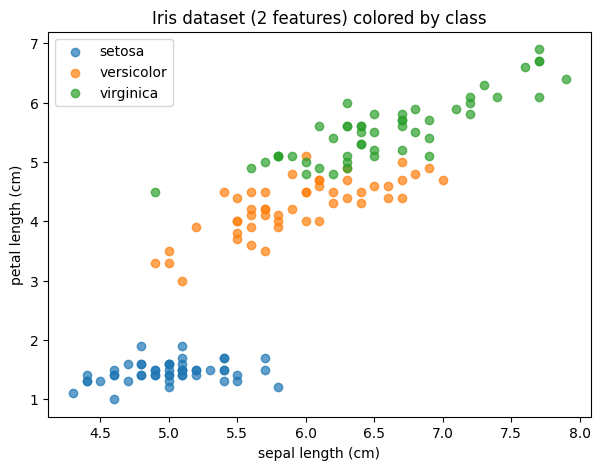

In [4]:
# 2) Visualize using two features
# We'll use feature 0 vs feature 2 (often shows separation)

f1, f2 = 0, 2

plt.figure(figsize=(7, 5))
for c in np.unique(y):
    plt.scatter(
        X[y == c, f1],
        X[y == c, f2],
        label=class_names[c],
        alpha=0.7
    )

plt.xlabel(feature_names[f1])
plt.ylabel(feature_names[f2])
plt.title("Iris dataset (2 features) colored by class")
plt.legend()
plt.show()

In [5]:
# 3) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [6]:
# 4) Scale AFTER split + 5) Train SVM using Pipeline
# We'll use RBF kernel (default is good). C controls regularization.

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
])

svm_pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(probability=True, random_state=42))])

In [7]:
# 6) Evaluate
y_pred = svm_pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0
